<a href="https://colab.research.google.com/github/Flosotoo/Ev1-DeepLearning/blob/main/DeepLearning-CIFAR10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Evaluación Parcial N°1
## Clasificación de imágenes con un perceptrón multicapa

* Asignatura: Deep Learning (DLY0100)
* Profesor: Matías Rojas
* Integrantes: Florencia Soto, Antonio Jara
* Fecha de entrega: 2 de octubre de 2026

# 1. Introducción

## 1.1 Propósito del estudio
El objetivo de este trabajo es implementar y evaluar una red neuronal artificial de tipo perceptrón multicapa, denominada MLP, capaz de clasificar imágenes a color en $10$ categorías.
Se hará uso práctico de tecnologías estudiadas a lo largo de la primera etapa del curso, tales como el perceptrón, funciones de activación, función de pérdida, función de salida, retropropagación, optimizadores y técnicas de regularización.

El problema consiste en una clasificación multiclase supervisada. A partir de un conjunto de pares (imagen y etiqueta), la red debe aprender una función que asigne a cada imagen nueva una de las $10$ clases posibles.

## 1.2 Conjunto de datos: CIFAR-10
Para el análisis, se utilizará el dataset CIFAR-10, publicado por la Universidad de Toronto (Alex Krizhevsky), el cual consta de $60\ 000$ imágenes en color de $32 \times 32$ píxeles, distribuidas en $10$ clases.

| Característica | Valor |
| --- | --- |
| Imágenes de entrenamiento | $50\ 000$ ($5$ lotes de $10\ 000$) |
| Imágenes de prueba | $10\ 000$ |
| Resolución | $32 \times 32$ píxeles, $3$ canales RGB |
| Dimensionalidad por imagen | $32 \times 32 \times 3 = 3\ 072$ valores |
| Rango de los píxeles | $0$ – $255$ (enteros, `uint8`) |
| Clases | airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck |
| Balance | $5\ 000$ imágenes por clase en entrenamiento |

## 1.3 Expectativa de desempeño y alcance del modelo
A diferencia de MNIST (donde un MLP simple supera el $97\ %$ de accuracy), un MLP en CIFAR-10 alcanza típicamente entre $45\%$ y $55\%$. Esto se debe a que, al aplanar la imagen a un vector de $3\ 072$ componentes, se destruye la estructura espacial (donde dos píxeles vecinos pasan a ser dos entradas sin relación alguna) y la red pierde la invariancia a la traslación (el objeto desplazado activa pesos completamente distintos).
Las redes convolucionales resuelven ambos problemas, pero quedan fuera de este análisis, ya que se requiere explícitamente el uso de un modelo MLP.

El piso del azar es del $10\ %$ y cualquier resultado sustancialmente superior indica un aprendizaje real del modelo.

## 1.4 Configuración del entorno y recursos
Por defecto, los pesos de la red neuronal se inicializan de forma aleatoria y no se puede saber si la mejora en los resultados se debe a los cambios en los parámetros o a la aleatoriedad. Fijar la semilla garantiza la reproducibilidad para realizar comparaciones controladas y correctamente medibles.

In [ ]:
import sys, os, pickle, time, gc, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

# Desactivamos el aviso de NumPy 2.x al cargar archivos pickle de Python 2 (como CIFAR-10) para no saturar la consola con avisos
warnings.filterwarnings('ignore', category=np.exceptions.VisibleDeprecationWarning)

SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

---

# 2. Obtención y Extracción de Archivos CIFAR

## 2.1 Acceso a los archivos

Se utiliza el archivo oficial `cifar-10-python.tar.gz`. Contiene los 8 archivos del dataset: `data_batch_1` … `data_batch_5`, `test_batch`, `batches.meta` y `readme.html`.

La celda siguiente es tolerante a fallos y evita descargas redundantes mediante los siguientes pasos:
1. Comprueba si los archivos ya han sido extraídos en el entorno temporal de Colab.
2. Si no están extraídos, busca si ya existe el archivo `.tar.gz`.
3. Si no detecta ni la carpeta extraída ni el archivo `.tar.gz`, procede a realizar la descarga automática usando `wget` desde el servidor oficial.
4. Una vez obtenido el archivo comprimido (sea por carga manual o por descarga), lo extrae en `/content`.

Cabe notar que el almacenamiento de `/content` es temporal, por lo que al cerrar la sesión de Colab, los datos se eliminarán.

In [ ]:
import os
import glob
import tarfile

ESPERADOS = ['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3',
             'data_batch_4', 'data_batch_5', 'test_batch']

def localizar_cifar():
    """Devuelve la carpeta que contiene los batches, o None si no los encuentra."""
    for carpeta in ['/content/cifar-10-batches-py', '/content']:
        if all(os.path.isfile(os.path.join(carpeta, f)) for f in ESPERADOS):
            return carpeta
    return None

# 1. Intentar localizar los archivos ya extraídos
RUTA = localizar_cifar()

if RUTA is None:
    # 2. Si no están extraídos, buscar si existe el .tar.gz
    tars = glob.glob('/content/*.tar.gz')
    if not tars:
        # No está el .tar.gz: lo descargamos
        print("Descargando CIFAR-10...")
        !wget -q https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
        tars = glob.glob('/content/*.tar.gz')

    # 3. Si tenemos el .tar.gz (ya sea existente o recién descargado), lo extraemos
    if tars:
        tar = tars[0]
        print(f"Extrayendo archivo: {os.path.basename(tar)}")
        with tarfile.open(tar, 'r:gz') as t:
            t.extractall('/content')
        RUTA = localizar_cifar()

assert RUTA is not None, "La extracción no produjo los archivos esperados."
print("RUTA =", RUTA)
print(sorted(os.listdir(RUTA)))

RUTA = /content/cifar-10-batches-py
['batches.meta', 'data_batch_1', 'data_batch_2', 'data_batch_3', 'data_batch_4', 'data_batch_5', 'readme.html', 'test_batch']


## 2.2 Lectura de los batches
Los archivos son diccionarios serializados con pickle de Python 2. El argumento `encoding='latin1'` es obligatorio para evitar un `UnicodeDecodeError` durante la lectura.

La matriz de datos contiene las imágenes en un formato plano de $3\ 072$ valores, organizados por canales de color consecutivos (primero $1\ 024$ valores de rojo, luego $1\ 024$ de verde y finalmente $1\ 024$ de azul). Para poder visualizar o procesar las imágenes en su formato espacial bidimensional, es necesario redimensionar y transponer la estructura utilizando `reshape(3, 32, 32).transpose(1, 2, 0)`.

In [ ]:
# Carga y validación del dataset
import os
import pickle
import numpy as np

# 1. Validación de la ruta de datos
if not os.path.exists(RUTA):
    raise FileNotFoundError(f"No se encuentra la carpeta de datos en la ruta especificada: {RUTA}")

# 2. Definición de la función de lectura
def cargar_lote_cifar(ruta_archivo):
    """Lee y carga un archivo individual de lote de CIFAR-10 usando pickle con codificación Latin-1."""
    with open(ruta_archivo, 'rb') as f:
        lote = pickle.load(f, encoding='latin1')
    return lote['data'], lote['labels']

# 3. Carga y consolidación de todos los lotes
X_lotes = []
y_lotes = []
for i in range(1, 6):
    ruta_lote = os.path.join(RUTA, f'data_batch_{i}')
    datos, etiquetas = cargar_lote_cifar(ruta_lote)
    X_lotes.append(datos)
    y_lotes.extend(etiquetas)

X_full = np.concatenate(X_lotes, axis=0)
y_full = np.array(y_lotes)

# 4. Carga del lote de prueba
ruta_test = os.path.join(RUTA, 'test_batch')
X_test_raw, y_test = cargar_lote_cifar(ruta_test)
X_test_raw = np.array(X_test_raw)
y_test = np.array(y_test)

# 5. Carga de los nombres de clases
ruta_meta = os.path.join(RUTA, 'batches.meta')
with open(ruta_meta, 'rb') as f:
    meta = pickle.load(f, encoding='latin1')
CLASES = meta['label_names']

# 6. Aserciones de validación de dimensiones e integridad
assert X_full.shape == (50000, 3072), "Se esperaban 50 000 imágenes de 3072 valores en el set de entrenamiento"
assert X_test_raw.shape == (10000, 3072), "Se esperaban 10 000 imágenes en el de prueba"
assert len(CLASES) == 10, "Se esperaban 10 nombres de clases"

print("Datos cargados y validados:")
print(f"  - Entrenamiento: {X_full.shape[0]} imágenes de {X_full.shape[1]} píxeles (flattened)")
print(f"  - Prueba: {X_test_raw.shape[0]} imágenes")
print(f"  - Clases: {CLASES}")

Datos cargados y validados:
  - Entrenamiento: 50000 imágenes de 3072 píxeles (flattened)
  - Prueba: 10000 imágenes
  - Clases: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 2.3 Exploración
### Distribución de clases
El balance de clases condiciona qué métricas son válidas: en un dataset balanceado, el accuracy es informativo y los promedios macro y weighted de precision/recall/F1 serán prácticamente idénticos.

0 airplane    :  5000 imágenes
1 automobile  :  5000 imágenes
2 bird        :  5000 imágenes
3 cat         :  5000 imágenes
4 deer        :  5000 imágenes
5 dog         :  5000 imágenes
6 frog        :  5000 imágenes
7 horse       :  5000 imágenes
8 ship        :  5000 imágenes
9 truck       :  5000 imágenes


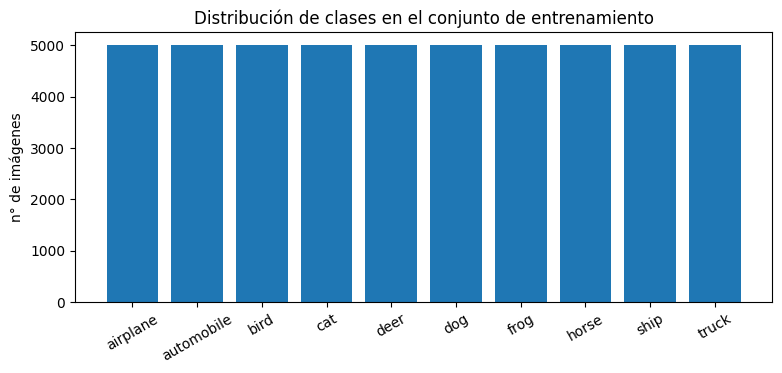

In [ ]:
conteo = np.bincount(y_full)
for i, c in enumerate(CLASES):
    print(f"{i} {c:12s}: {conteo[i]:5d} imágenes")

plt.figure(figsize=(9, 3.5))
plt.bar(CLASES, conteo)
plt.title('Distribución de clases en el conjunto de entrenamiento')
plt.ylabel('n° de imágenes')
plt.xticks(rotation=30)
plt.show()

El conjunto de entrenamiento está perfectamente balanceado con 5 000 imágenes para cada una de las 10 clases. Esto tiene dos consecuencias:
1. El accuracy es una métrica representativa, ya que no existe una clase mayoritaria que pueda inflarlo artificialmente. Un modelo que siempre prediga la misma clase obtendrá solo un 10 %.
2. Los promedios macro y weighted de precision, recall y F1 serán prácticamente iguales, porque todas las clases tienen el mismo peso.

## 2.4 Exploración visual
Revisar las imágenes antes de entrenar permite confirmar que la decodificación es correcta y que las etiquetas corresponden a lo que se ve. Si las imágenes salieran con colores extraños o como franjas, significaría que se omitió el transpose y la carga estaría mal.

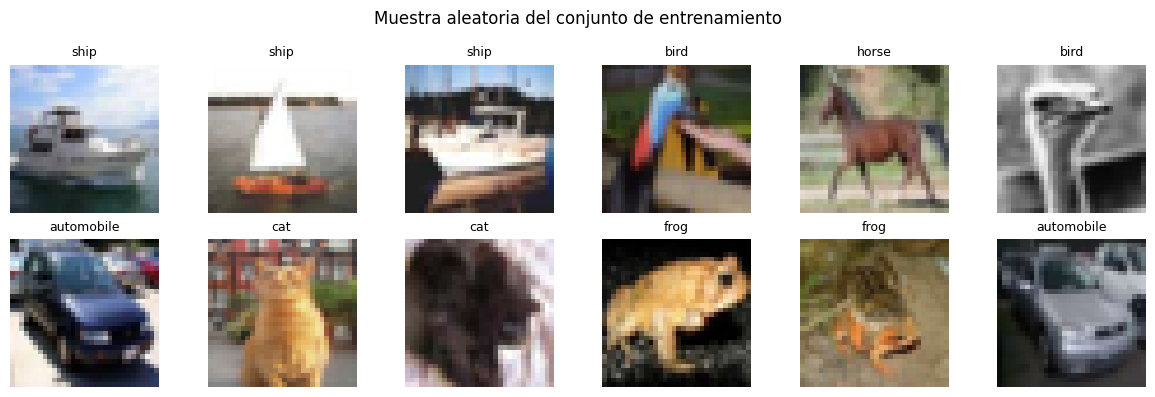

In [ ]:
def a_imagen(fila):
    """3072 valores en formato CIFAR (planos R,G,B) -> (32,32,3) para imshow."""
    return fila.reshape(3, 32, 32).transpose(1, 2, 0)

fig, axs = plt.subplots(2, 6, figsize=(12, 4))
for ax in axs.ravel():
    k = np.random.randint(len(X_full))
    ax.imshow(a_imagen(X_full[k])); ax.axis('off')
    ax.set_title(CLASES[y_full[k]], fontsize=9)
plt.suptitle('Muestra aleatoria del conjunto de entrenamiento')
plt.tight_layout(); plt.show()

Las imágenes se decodifican correctamente y sus etiquetas coinciden con el contenido, lo que valida el proceso de carga. Se observa una alta variabilidad intraclase: los objetos aparecen con distintos fondos, posiciones, escalas y ángulos. Esto anticipa que el MLP, al no contar con invariancia a la traslación, tendrá dificultades para distinguir clases similares.

## 2.5 División train / validación / test

- Entrenamiento ($45\ 000$): se usa para ajustar los pesos.
- Validación ($5\ 000$): se usa para tomar decisiones sobre hiperparámetros y detectar sobreajuste.
- Prueba ($10\ 000$): se reserva y no se observa hasta la evaluación final.

Se usa `stratify` para conservar la proporción de las $10$ clases en ambos subconjuntos.
Si se ajustaran hiperparámetros mirando el conjunto de prueba, el resultado final dejaría de medir generalización, porque se habría filtrado información del test al proceso de diseño.

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(
    X_full, y_full, test_size=0.10, random_state=SEMILLA, stratify=y_full)
del X_full, y_full; gc.collect()

print("Train     :", X_tr.shape)
print("Validación:", X_val.shape)
print("Test      :", X_test_raw.shape)
print("Balance en validación:", np.bincount(y_val))

Train     : (45000, 3072)
Validación: (5000, 3072)
Test      : (10000, 3072)
Balance en validación: [500 500 500 500 500 500 500 500 500 500]


## 2.6 Escalado y codificación one-hot

(a) Conversión a `float32` y estandarización. Con entradas en el rango $0$–$255$, la preactivación $u = \sum x_i w_i + b$ toma valores muy grandes, lo que desestabiliza el entrenamiento y produce gradientes erráticos. Se aplica estandarización (media $0$, desviación $1$) porque, además de acotar el rango, centra los datos: la superficie de costo se vuelve más isotrópica y el descenso de gradiente converge de forma más rápida y directa.

(b) Estadísticas calculadas SOLO con el conjunto de entrenamiento. Calcular $\mu$ y $\sigma$ usando también validación o test constituiría fuga de información (data leakage) e invalidaría la evaluación.

(c) Codificación one-hot de las etiquetas. La salida de la red es un vector de $10$ probabilidades (softmax) y la entropía cruzada categórica compara distribución contra distribución. Además, dejar la etiqueta como entero sugeriría un orden numérico inexistente: la clase $8$ (ship) no está "más cerca" de la $9$ (truck) que de la $0$ (airplane); son categorías, no cantidades.

(d) Sobre el aplanado. Los datos ya vienen como vectores de $3\ 072$ componentes, el formato que requiere una capa `Dense`. El costo de esta representación es la pérdida de la estructura espacial, discutida en la sección 1.3.

(e) Uso de memoria. Las operaciones se hacen in-place (`-=`, `/=`) para no duplicar los arreglos: en `float32` el conjunto de entrenamiento ocupa unos $550\ \text{MB}$.

In [ ]:
X_tr   = X_tr.astype('float32')
X_val  = X_val.astype('float32')
X_test = X_test_raw.astype('float32')
del X_test_raw; gc.collect()

# Estadísticas calculadas SOLO con train
mu    = X_tr.mean(axis=0)
sigma = X_tr.std(axis=0) + 1e-7

for arr in (X_tr, X_val, X_test):
    arr -= mu       # in-place: no crea copias
    arr /= sigma

Y_tr   = keras.utils.to_categorical(y_tr,   10)
Y_val  = keras.utils.to_categorical(y_val,  10)
Y_test = keras.utils.to_categorical(y_test, 10)

print("X_tr :", X_tr.shape, X_tr.dtype, f"| media={X_tr.mean():.4f} std={X_tr.std():.4f}")
print("Y_tr :", Y_tr.shape)
print("Ejemplo de one-hot | etiqueta", y_tr[0], f"({CLASES[y_tr[0]]}) ->", Y_tr[0].astype(int))

N_ENTRADA = X_tr.shape[1]   # 3072
N_CLASES  = Y_tr.shape[1]   # 10

X_tr : (45000, 3072) float32 | media=-0.0000 std=1.0000
Y_tr : (45000, 10)
Ejemplo de one-hot | etiqueta 1 (automobile) -> [0 1 0 0 0 0 0 0 0 0]


# 3. Definición del modelo
## 3.1 Arquitectura propuesta
Estructura en embudo: $3\ 072 \rightarrow 512 \rightarrow 256 \rightarrow 128 \rightarrow 10$. Cada capa produce una representación más compacta y abstracta que la anterior; la primera capa debe ser ancha porque la entrada lo es.

| Capa | Cálculo | Parámetros |
| --- | --- | --- |
| Dense 512 | $3\ 072 \cdot 512 + 512$ | $1\ 573\ 376$ |
| Dense 256 | $512 \cdot 256 + 256$ | $131\ 328$ |
| Dense 128 | $256 \cdot 128 + 128$ | $32\ 896$ |
| Dense 10 (salida) | $128 \cdot 10 + 10$ | $1\ 290$ |
| Total | | $1\ 738\ 890$ |

## 3.2 Funciones seleccionadas
| Componente | Elección | Justificación |
| --- | --- | --- |
| Activación oculta | ReLU | No satura en el lado positivo (derivada $= 1$), evitando el desvanecimiento del gradiente de sigmoide y tanh; computacionalmente barata |
| Inicialización | He normal, $\sqrt{2/n}$ | Adecuada para ReLU: compensa que ReLU anula la mitad de las activaciones, conservando la varianza entre capas |
| Función de salida | Softmax | $10$ clases mutuamente excluyentes; salidas en $[0,1]$ que suman $1$, interpretables como probabilidades |
| Función de pérdida | Categorical cross-entropy | Correcta para softmax con etiquetas one-hot; penaliza fuerte la confianza equivocada y su gradiente respecto de los logits es $\hat{y} - y$ |
| Optimizador (base) | Adam, $lr = 10^{-3}$ | Combina momentum y tasas adaptativas por parámetro; converge rápido |
| Métrica de monitoreo | accuracy | Legítima por el balance de clases; no es derivable, por eso se monitorea pero no se optimiza |

## 3.3 Funciones reutilizables
Para que los experimentos sean controlados, todos los modelos se construyen con la misma función parametrizada y se entrenan con el mismo procedimiento.

In [ ]:
def construir_mlp(capas=(512, 256, 128), activacion='relu', dropout=0.0,
                  l2=0.0, batchnorm=False,
                  n_entrada=N_ENTRADA, n_clases=N_CLASES):
    """Construye un MLP parametrizable.

    capas      : tupla con el n° de neuronas de cada capa oculta
    activacion : 'relu' | 'tanh' | 'sigmoid' | 'elu'
    dropout    : fracción de neuronas apagadas tras cada capa oculta (0 = sin dropout)
    l2         : coeficiente de regularización L2 sobre los pesos (0 = sin L2)
    batchnorm  : si True, inserta BatchNormalization entre la capa densa y la activación
    """
    modelo = keras.Sequential([keras.Input(shape=(n_entrada,))])
    for u in capas:
        modelo.add(layers.Dense(
            u,
            use_bias=not batchnorm,   # con BN el bias es redundante (lo cumple beta)
            kernel_initializer='he_normal' if activacion in ('relu', 'elu') else 'glorot_uniform',
            kernel_regularizer=regularizers.l2(l2) if l2 > 0 else None))
        if batchnorm:
            modelo.add(layers.BatchNormalization())
        modelo.add(layers.Activation(activacion))
        if dropout > 0:
            modelo.add(layers.Dropout(dropout))
    modelo.add(layers.Dense(n_clases, activation='softmax'))
    return modelo


def entrenar(modelo, optimizador='adam', lr=1e-3, epochs=40, batch_size=128,
             loss='categorical_crossentropy', paciencia=8, verbose=0):
    """Compila y entrena un modelo con early stopping sobre val_loss."""
    opt = {'adam':    keras.optimizers.Adam(learning_rate=lr),
           'sgd':     keras.optimizers.SGD(learning_rate=lr),
           'sgdm':    keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True),
           'rmsprop': keras.optimizers.RMSprop(learning_rate=lr)}[optimizador]
    modelo.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
    cbs = [callbacks.EarlyStopping(monitor='val_loss', patience=paciencia,
                                   restore_best_weights=True)]
    return modelo.fit(X_tr, Y_tr, validation_data=(X_val, Y_val),
                      epochs=epochs, batch_size=batch_size,
                      callbacks=cbs, verbose=verbose)


def curvas(hists, titulo='', claves=('loss', 'accuracy')):
    """Grafica train (línea continua) vs validación (punteada) para varios historiales."""
    fig, axs = plt.subplots(1, len(claves), figsize=(6.5*len(claves), 4))
    axs = np.atleast_1d(axs)
    for ax, clave in zip(axs, claves):
        for nombre, h in hists.items():
            p = ax.plot(h.history[clave], label=f'{nombre} (train)')
            ax.plot(h.history['val_'+clave], '--', color=p[0].get_color(),
                    label=f'{nombre} (val)')
        ax.set_xlabel('epoch'); ax.set_ylabel(clave)
        ax.set_title(clave); ax.grid(alpha=.3); ax.legend(fontsize=7)
    plt.suptitle(titulo); plt.tight_layout(); plt.show()

print("Funciones listas.")

Funciones listas.


##3.4 Verificacion de la arquitectura


In [ ]:
modelo_demo = construir_mlp()
modelo_demo.summary()
del modelo_demo

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_36 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_27 (Activation)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_28 (Activation)      │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_29 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,738,890 (6.63 MB)

 Trainable params: 1,738,890 (6.63 MB)

 Non-trainable params: 0 (0.00 B)

El total reportado coincide con el cálculo manual. El 90 % de los parámetros se concentra en la primera capa, porque la entrada es muy ancha (de 3 072). La red tiene muchos más parámetros que ejemplos de entrenamiento, lo que le da una enorme capacidad de memorización: anticipamos que el sobreajuste será el principal riesgo y que las técnicas de regularización serán necesarias y no opcionales.

# 4. Entrenamiento base y motor de experimentos
## 4.1 Registro automático de experimentos
Cada experimento se ejecuta con la misma semilla y se registra en una tabla común. La columna `brecha` (train_acc $-$ val_acc) es el indicador directo de sobreajuste. Los resultados se guardan en `resultados_experimentos.csv` después de cada corrida, para no perderlos si la sesión se desconecta.

Cuando un experimento tiene exactamente la misma configuración que uno ya entrenado (por ejemplo, $lr = 10^{-3}$ en el bloque de tasas de aprendizaje es idéntico al baseline), se reutiliza el resultado en lugar de volver a entrenar, para ahorrar tiempo de GPU.

In [ ]:
resultados  = []   # filas de la tabla comparativa
historiales = {}   # historiales de entrenamiento, para graficar

def _guardar():
    pd.DataFrame(resultados).to_csv('resultados_experimentos.csv', index=False)

def experimento(nombre, cfg):
    """Entrena una configuración, la registra y devuelve (modelo, history)."""
    tf.random.set_seed(SEMILLA)          # misma inicialización en todos los experimentos
    np.random.seed(SEMILLA)
    kw_modelo = {k: v for k, v in cfg.items()
                 if k in ('capas', 'activacion', 'dropout', 'l2', 'batchnorm')}
    kw_train  = {k: v for k, v in cfg.items()
                 if k in ('optimizador', 'lr', 'epochs', 'batch_size', 'loss', 'paciencia')}
    m  = construir_mlp(**kw_modelo)
    t0 = time.time()
    h  = entrenar(m, **kw_train)
    dur = time.time() - t0

    i = int(np.argmin(h.history['val_loss']))   # mejor epoch (la restaurada por EarlyStopping)
    fila = {'experimento': nombre,
            **{k: str(v) for k, v in cfg.items()},
            'epocas': len(h.history['loss']),
            'train_acc': round(h.history['accuracy'][i], 4),
            'val_acc':   round(h.history['val_accuracy'][i], 4),
            'val_loss':  round(h.history['val_loss'][i], 4),
            'brecha':    round(h.history['accuracy'][i] - h.history['val_accuracy'][i], 4),
            'seg': round(dur, 1)}
    resultados.append(fila); historiales[nombre] = h; _guardar()
    print(f"{nombre:28s} | val_acc={fila['val_acc']:.4f} | brecha={fila['brecha']:+.4f} "
          f"| {fila['epocas']} epochs | {fila['seg']}s")
    return m, h

def reutilizar(origen, nombre, etiquetas):
    """Registra un experimento ya entrenado bajo otro nombre (misma configuración)."""
    fila = dict(next(r for r in resultados if r['experimento'] == origen))
    fila['experimento'] = nombre
    fila.update({k: str(v) for k, v in etiquetas.items()})
    resultados.append(fila); historiales[nombre] = historiales[origen]; _guardar()
    print(f"{nombre:28s} | (reutilizado de {origen}) val_acc={fila['val_acc']:.4f}")

def tabla(prefijo=None, columnas=None):
    df = pd.DataFrame(resultados)
    if prefijo:
        df = df[df['experimento'].str.startswith(prefijo)]
    df = df.dropna(axis=1, how='all')
    return df[columnas] if columnas else df

print("Motor de experimentos listo.")

Motor de experimentos listo y corregido.


## 4.2 Modelo base (baseline)
Configuración de partida, con los tres parámetros clave explícitos:

- epochs: $40$ máximo, con early stopping (`patience=8`): el entrenamiento se detiene cuando la pérdida de validación deja de mejorar durante $8$ epochs y se restauran los mejores pesos.
- Tasa de aprendizaje: $10^{-3}$ (valor recomendado para Adam).
- Tamaño de batch: $128$ (compromiso entre velocidad de cómputo y calidad del gradiente).

Estrategia: el baseline se entrena sin regularización a propósito. Un modelo que no es capaz de sobreajustar tampoco es capaz de aprender; primero se verifica que la arquitectura tiene capacidad suficiente y después se la contiene.

E0_baseline                  | val_acc=0.4752 | brecha=+0.0396 | 11 epochs | 19.6s


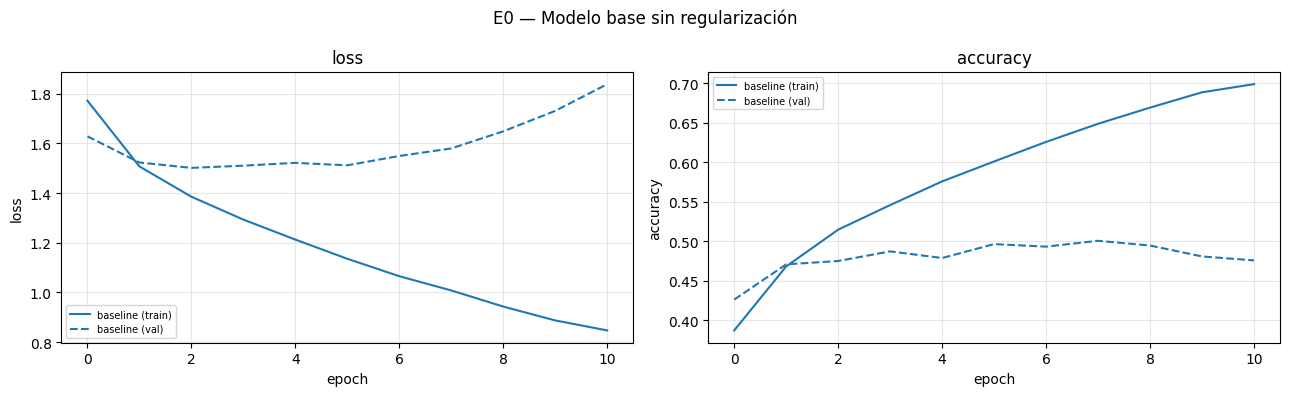

In [ ]:
m_base, h_base = experimento('E0_baseline', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 128
})
curvas({'baseline': h_base}, 'E0 — Modelo base sin regularización')

El modelo base alcanzó una val_accuracy de $47.52\ %$, $4.8$ veces superior al azar ($10\ %$) y dentro del rango esperado para un MLP en CIFAR-10 (entre $45\ %$ y $55\ %$), lo que confirma que la red aprende patrones reales. Sin embargo, las curvas muestran un sobreajuste temprano y marcado, ya que la pérdida de validación alcanza su mínimo ($1.50$) en la epoch $3$ y desde ahí aumenta hasta $1.83$, mientras que la curva de entrenamiento continúa descendiendo hasta $0.85$. Al final del entrenamiento, la accuracy de entrenamiento llega al $70\ %$ frente al $47.5\ %$ en validación, con una brecha de $22$ puntos.

La brecha de $4$ puntos reportada en la tabla corresponde a la epoch $3$, cuyos pesos restauró el EarlyStopping, y no refleja el sobreajuste que se desarrolló después. Se observa, además, que la val_accuracy sigue subiendo levemente (hasta el $50\ %$) en la epoca 8 y luego cae a $47.5$%, mientras que val_loss aumenta, provocando que el modelo acierte un poco más pero sus errores sean más confiados; esto hace que la entropía cruzada penalice dicha confianza.

Esto confirma lo anticipado en la sección 3.4 para un modelo con $1.74$ millones de parámetros para $45\ 000$ ejemplos. La red memoriza rápidamente y la regularización es necesaria.

# 5. Experimentos controlados
En cada bloque se varía un solo hiperparámetro, manteniendo todos los demás en los valores baseline ($3$ capas de $512$, $256$, $128$, ReLU, Adam, $lr=10^{-3}$, batch=$128$, sin regularización).

## 5.1 Impacto de la tasa de aprendizaje
La tasa de aprendizaje $\alpha$ controla el tamaño del paso en $$\theta - \alpha \cdot \nabla L \rightarrow \theta$$
Es el parámetro más influyente: si es demasiado pequeño hace el entrenamiento interminable; demasiado grande produce un comportamiento errático (la trayectoria "rebota" sin converger).

E1_lr=0.01                   | val_acc=0.3306 | brecha=+0.0082 | 18 epochs | 30.2s
E1_lr=0.001                  | (reutilizado de E0_baseline) val_acc=0.4752
E1_lr=0.0001                 | val_acc=0.4976 | brecha=+0.1234 | 13 epochs | 23.4s


,experimento,lr,epocas,train_acc,val_acc,brecha,seg
1,E1_lr=0.01,0.01,18,0.3388,0.3306,0.0082,30.2
2,E1_lr=0.001,0.001,11,0.5148,0.4752,0.0396,19.6
3,E1_lr=0.0001,0.0001,13,0.6210,0.4976,0.1234,23.4


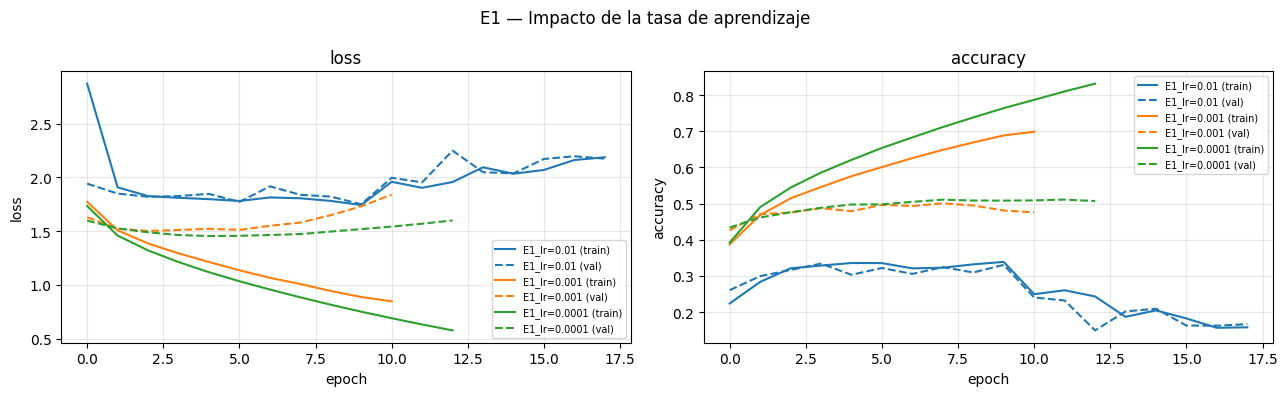

In [ ]:
experimento('E1_lr=0.01', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-2,
    'epochs': 40,
    'batch_size': 128
})

reutilizar('E0_baseline', 'E1_lr=0.001', {'lr': 1e-3})

experimento('E1_lr=0.0001', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-4,
    'epochs': 40,
    'batch_size': 128
})

display(tabla('E1', ['experimento', 'lr', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E1')},
       'E1 — Impacto de la tasa de aprendizaje')

Con $lr = 0.01$ el entrenamiento diverge. La pérdida inicial se dispara a $2.87$ y, tras estancarse cerca de $1.8$, vuelve a aumentar desde la epoch $10$ hasta $2.2$, mientras la accuracy de entrenamiento cae de $34\%$ a $16\%$. Su mejor val_accuracy fue $33.06\%$, la peor de todos los experimentos. Su brecha mínima ($0.8$ puntos) no indica buena generalización sino un subajuste severo: el paso es tan grande que el optimizador se aleja del mínimo en lugar de asentarse en él, un comportamiento vecino a la explosión del gradiente.

Con $lr = 0.0001$ se obtuvo la mejor val_accuracy del bloque ($49.76\%$), pero también la mayor brecha ($12.3$ puntos), con una accuracy de entrenamiento que escala hasta $83\%$ en $13$ epochs.

La interpretación es que, con Adam sobre $1.7$ millones de parámetros y entradas de $3\ 072$ dimensiones, el paso de $0.001$ introduce más ruido en la trayectoria, mientras que $0.0001$ sigue el valle de la función de costo con mayor precisión.

Se mantiene $lr = 0.001$ en la configuración final, porque se combina con Batch Normalization, que estabiliza las activaciones y tolera tasas mayores. Evaluar $lr = 0.0001$ dentro de la configuración regularizada queda como trabajo futuro.



## 5.2 Impacto del tamaño de batch
El batch size determina cuántos ejemplos se procesan antes de cada actualización de pesos. Lotes pequeños producen más actualizaciones por epoch (gradiente más ruidoso, que actúa como regularizador leve, pero más lento en tiempo real); lotes grandes aprovechan mejor la GPU pero realizan menos actualizaciones con el mismo número de epochs.

| Batch | Actualizaciones por epoch ($45\ 000$ ejemplos) |
| --- | --- |
| $32$ | $\approx 1\ 407$ |
| $128$ | $\approx 352$ |
| $512$ | $\approx 88$ |

E2_batch=32                  | val_acc=0.4874 | brecha=+0.0428 | 12 epochs | 58.0s
E2_batch=128                 | (reutilizado de E0_baseline) val_acc=0.4752
E2_batch=512                 | val_acc=0.4930 | brecha=+0.1072 | 13 epochs | 15.7s


,experimento,batch_size,epocas,train_acc,val_acc,brecha,seg
4,E2_batch=32,32,12,0.5302,0.4874,0.0428,58.0
5,E2_batch=128,128,11,0.5148,0.4752,0.0396,19.6
6,E2_batch=512,512,13,0.6002,0.4930,0.1072,15.7


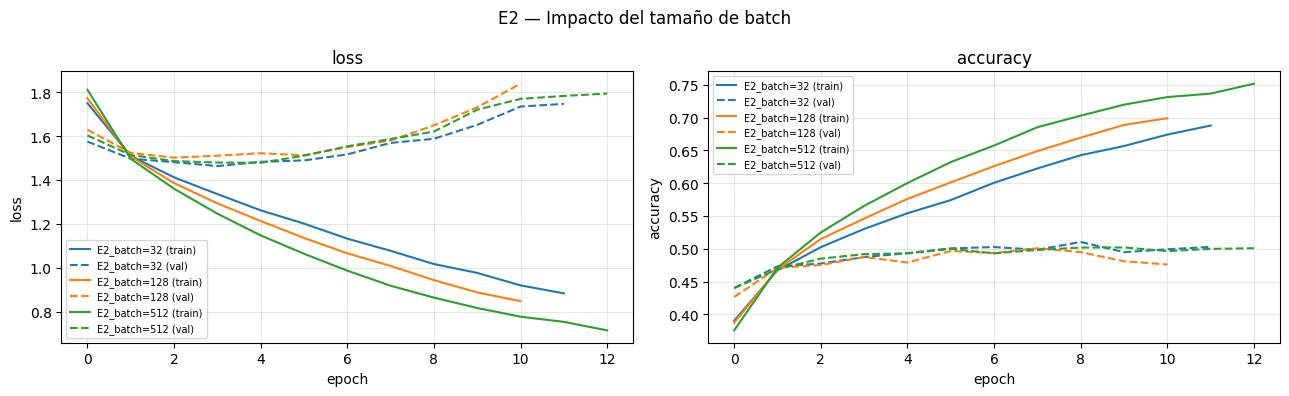

In [ ]:
experimento('E2_batch=32', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 32
})

reutilizar('E0_baseline', 'E2_batch=128', {'batch_size': 128})

experimento('E2_batch=512', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 512
})

display(tabla('E2', ['experimento', 'batch_size', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E2')},
       'E2 — Impacto del tamaño de batch')

Las diferencias entre tamaños de batch fueron pequeñas ($1.8$ puntos). $Batch = 512$ obtuvo la mayor val_accuracy ($49.30\%$) y fue el más rápido ($15.7 s$), pero también la mayor brecha ($10.7$ puntos): con solo $88$ actualizaciones por epoch, el gradiente es más estable y el modelo ajusta con más precisión el conjunto de entrenamiento. $Batch = 32$ obtuvo $48.74\%$ y tardó $58.0 s$, tres veces más que $batch = 128$ ($19.6 s$, $47.52\%$), porque realiza $1 407$ actualizaciones por epoch y aprovecha peor el paralelismo de la GPU.

Dado que las diferencias de accuracy son menores a $2$ puntos, se elige $batch = 128$ como compromiso entre tiempo de cómputo, accuracy y brecha: $batch = 512$ obtuvo el mejor número, pero con el mayor sobreajuste del bloque.



## 5.3 Impacto de la arquitectura
Al aumentar neuronas o capas crece drásticamente la cantidad de parámetros y, con ello, el tiempo de entrenamiento y la capacidad de memorización. No existe una fórmula para elegir estos valores.

| Arquitectura | Parámetros aprox. |
| --- | --- |
| $1$ capa ($256$) | $789\ 000$ |
| $3$ capas ($512$-$256$-$128$) | $1\ 739\ 000$ |
| $4$ capas ($1024$-$512$-$256$-$128$) | $3\ 836\ 000$ |

E3_capas=1x256               | val_acc=0.4810 | brecha=+0.1074 | 13 epochs | 20.0s
E3_capas=3x512               | (reutilizado de E0_baseline) val_acc=0.4752
E3_capas=4x1024              | val_acc=0.4912 | brecha=+0.0491 | 12 epochs | 24.0s


,experimento,capas,epocas,train_acc,val_acc,brecha,seg
7,E3_capas=1x256,"(256,)",13,0.5884,0.4810,0.1074,20.0
8,E3_capas=3x512,"(512, 256, 128)",11,0.5148,0.4752,0.0396,19.6
9,E3_capas=4x1024,"(1024, 512, 256, 128)",12,0.5403,0.4912,0.0491,24.0


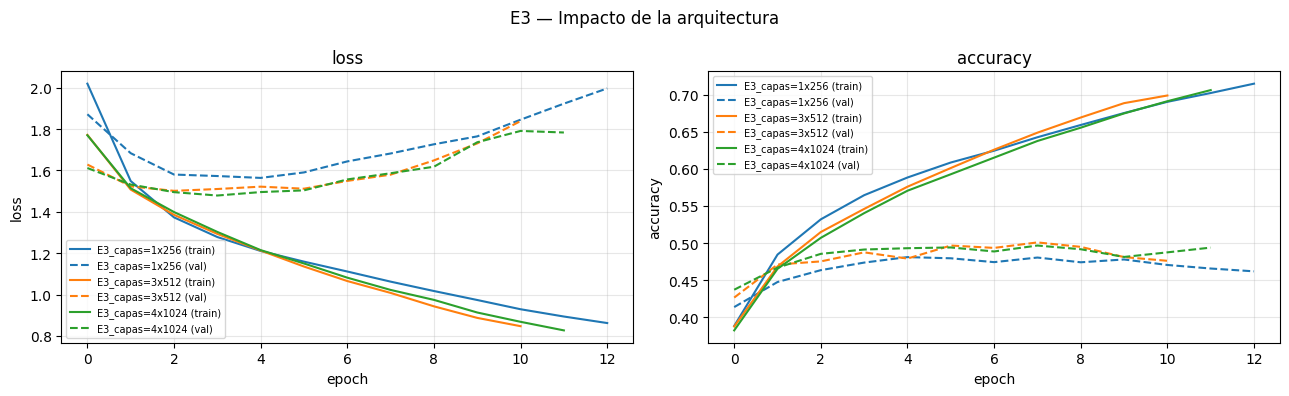

In [ ]:
experimento('E3_capas=1x256', {
    'capas': (256,),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 128
})

reutilizar('E0_baseline', 'E3_capas=3x512', {'capas': (512, 256, 128)})

experimento('E3_capas=4x1024', {
    'capas': (1024, 512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 128
})

display(tabla('E3', ['experimento', 'capas', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E3')},
       'E3 — Impacto de la arquitectura')

La arquitectura fue el hiperparámetro de menor impacto. Las tres configuraciones quedaron dentro de $1.4$ puntos de diferencia:
- La red de $4$ capas ($1024$-$512$-$256$-$128$, con $3.8$ millones de parámetros) obtuvo $49.12\ %$.
- La red de $3$ capas obtuvo $47.52\ %$.
- La red de una sola capa, con $256$ neuronas ($0.8$ millones), obtuvo un $48.10\ %$.

Más que duplicar la cantidad de parámetros, aportó apenas $1.6$ puntos de val_accuracy.

Este resultado es coherente con la limitación planteada en la sección $1.3$: el techo de desempeño no lo impone la cantidad de neuronas, sino la representación aplanada de la imagen. Más capacidad no le devuelve al MLP la estructura espacial que pierde al aplanar. Y dado que las diferencias son del orden de un punto y cada configuración se entrenó una sola vez, no se consideran concluyentes y se decide mantener la arquitectura de $3$ capas como un equilibrio razonable entre capacidad y costo.

## 5.4 Comparación de funciones de activación
Se comparan cuatro activaciones en las capas ocultas, manteniendo softmax en la salida.

| Función | Rango | Derivada | Comportamiento esperado |
| --- | --- | --- | --- |
| ReLU | [0, ∞) | $1$ si $u>0$, $0$ si $u<0$ | No satura en el lado positivo: el gradiente no desaparece |
| ELU | (−1, ∞) | suave en negativos | Similar a ReLU; evita neuronas "muertas" |
| Tanh | (−1, 1) | $1$ − $\tanh^2(u)$ | Centrada en $0$, pero satura en los extremos |
| Sigmoide | (0, 1) | $\sigma(u)(1-\sigma(u)) \le 0.25$ | Satura y su derivada máxima es $0.25$: en varias capas el gradiente se desvanece |

E4_act=relu                  | (reutilizado de E0_baseline) val_acc=0.4752
E4_act=elu                   | val_acc=0.4786 | brecha=+0.0580 | 11 epochs | 21.3s
E4_act=tanh                  | val_acc=0.4522 | brecha=+0.0862 | 18 epochs | 31.0s
E4_act=sigmoid               | val_acc=0.4738 | brecha=+0.0387 | 13 epochs | 22.4s


,experimento,activacion,epocas,train_acc,val_acc,val_loss,brecha,seg
10,E4_act=relu,relu,11,0.5148,0.4752,1.5014,0.0396,19.6
11,E4_act=elu,elu,11,0.5366,0.4786,1.4979,0.0580,21.3
12,E4_act=tanh,tanh,18,0.5384,0.4522,1.5593,0.0862,31.0
13,E4_act=sigmoid,sigmoid,13,0.5125,0.4738,1.4842,0.0387,22.4


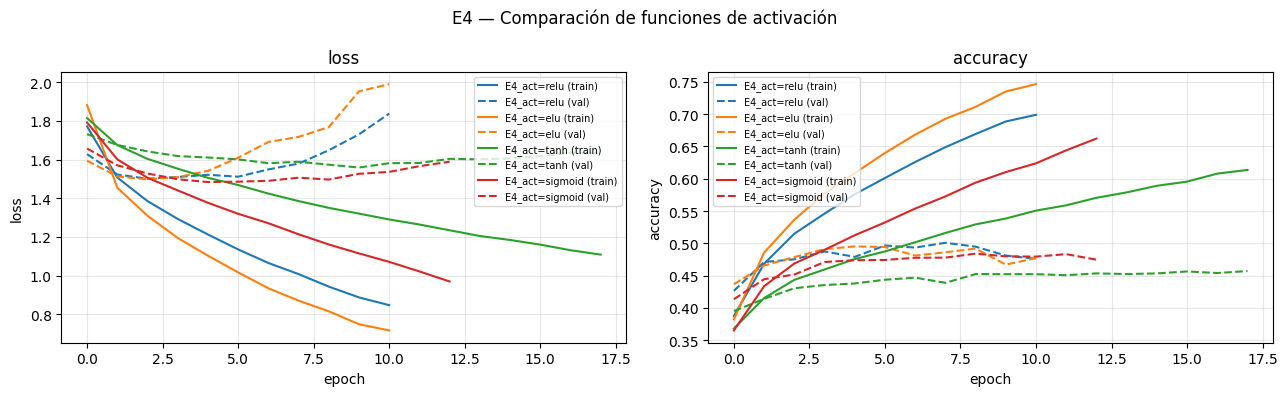

In [ ]:
reutilizar('E0_baseline', 'E4_act=relu', {'activacion': 'relu'})

for act in ['elu', 'tanh', 'sigmoid']:
    experimento(f'E4_act={act}', {
        'capas': (512, 256, 128),
        'activacion': act,
        'optimizador': 'adam',
        'lr': 1e-3,
        'epochs': 40,
        'batch_size': 128
    })

display(tabla('E4', ['experimento', 'activacion', 'epocas', 'train_acc',
                     'val_acc', 'val_loss', 'brecha', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E4')},
       'E4 — Comparación de funciones de activación')

| Activación | val_accuracy | val_loss | epochs | Brecha | Observación |
| --- | --- | --- | --- | --- | --- |
| ReLU | $47.52\ %$ | $1.5014$ | $11$ | $3.96$ | Aprende rápido, sobreajusta rápido |
| ELU | $47.86\ %$ | $1.4979$ | $11$ | $5.80$ | La más rápida en entrenamiento, pero con mayor brecha |
| Tanh | $45.20\ %$ | $1.5593$ | $18$ | $8.62$ | Peor desempeño y de aprendizaje más lento |
| Sigmoide | $47.38\ %$ | $1.4842$ | $13$ | $3.87$ | Aprende más lento, pero empata con ReLU |

Contra lo esperado, la sigmoide no fue la peor, ya que obtuvo $47.38\ %$ y es prácticamente igual que ReLU ($47.52\ %$). El efecto del desvanecimiento del gradiente sí es visible, pero en la velocidad de aprendizaje y no en el resultado final. En la epoch $6$, la accuracy en entrenamiento era del $60\ %$ con ReLU y $64\ %$ con ELU, frente al $53\ %$ con sigmoide y $49\ %$ con tanh.

Con solo $3$ capas ocultas, la atenuación del gradiente (de máximo $0.016$) frena el aprendizaje pero no lo bloquea, y Adam lo compensa en parte ya que normaliza el paso de cada parámetro por la magnitud de su gradiente. En una red más profunda, el efecto sería mucho más severo.

Este aprendizaje más lento tuvo, además, un efecto lateral, siendo que la sigmoide sobreajustó más tarde (siendo su mejor epoch la $5$, frente a la mejor epoch de ReLU siendo la $3$), y el early stopping la capturó en un punto más favorable. Tanh fue la peor (con $45.20\ %$), siendo el aprendizaje más lento en entrenamiento y con una val_accuracy estancada cerca del $45\ %$ desde la epoch $4$, siendo consistente con la saturación de sus extremos.

Se elige ReLU porque su diferencia con ELU (de $0.34$ puntos) y con la sigmoide (de $0.14$) no son significativas, sino computacionalmente más barata, y es coherente con la inicialización He y, a diferencia de la sigmoide, escala a redes profundas sin desvanecimiento del gradiente.

## 5.5 Comparación de funciones de pérdida
Se compara la entropía cruzada categórica con el error cuadrático medio (MSE), ambos sobre la misma salida softmax.

Con softmax + entropía cruzada, el gradiente respecto de los logits se simplifica a $\hat{y} - y$, una señal proporcional al error. Con softmax + MSE aparece un factor adicional derivado de la softmax que se anula cuando la red está saturada y equivocada, de modo que el entrenamiento se estanca precisamente cuando más necesita corregirse.

E5_loss=crossentropy         | (reutilizado de E0_baseline) val_acc=0.4752
E5_loss=mse                  | val_acc=0.4952 | brecha=+0.0987 | 15 epochs | 25.5s


,experimento,loss,epocas,train_acc,val_acc,brecha,seg
14,E5_loss=crossentropy,categorical_crossentropy,11,0.5148,0.4752,0.0396,19.6
15,E5_loss=mse,mse,15,0.5939,0.4952,0.0987,25.5


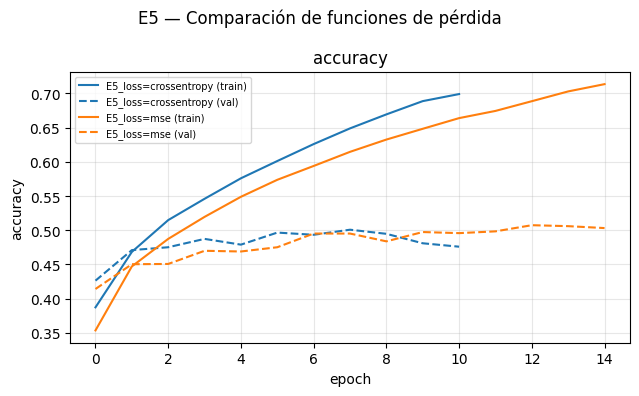

In [ ]:
reutilizar('E0_baseline', 'E5_loss=crossentropy', {'loss': 'categorical_crossentropy'})

experimento('E5_loss=mse', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 128,
    'loss': 'mse'
})

display(tabla('E5', ['experimento', 'loss', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']))
# La val_loss NO es comparable entre pérdidas distintas (escalas diferentes): se compara accuracy.
curvas({k: v for k, v in historiales.items() if k.startswith('E5')},
       'E5 — Comparación de funciones de pérdida', claves=('accuracy',))

El MSE obtuvo una val_accuracy mayor (de $49.52\ %$) que la entropía cruzada (de $47.52\ %$), pero el gráfico muestra que esta ventaja no se debe a que el MSE aprenda mejor. Con entropía cruzada, la accuracy de entrenamiento es mayor en todas las epochs, es decir, converge más rápido y, al igual número de epochs, ambas alcanzan una val_accuracy similar (del $50\ %$ hacia la epoch $8$).

La diferencia es un efecto del criterio de detención. La entropía cruzada penaliza fuertemente los errores con alta confianza, de forma que val_loss comienza a subir muy temprano (en su epoch $3$), aunque la val_accuracy todavía mejore levemente y el early stopping la detiene. El MSE, al estar acotado, castiga menos esa sobreconfianza: su val_loss sigue disminuyendo por más tiempo y el entrenamiento continúa hasta la epoch $15$. El MSE no aprende mejor, simplemente entrena por más tiempo. Una comparación justa requeriría monitorear val_accuracy o comparar a igual número de epochs.

Las val_loss de ambas configuraciones no son comparables entre sí, ya que miden magnitudes distintas en escalas distintas. Se mantiene la entropía cruzada por ser la pérdida estadísticamente correcta para una salida softmax sobre clases excluyentes, y porque su gradiente respecto a los logits produce la convergencia más rápida observada.

## 5.6 Comparación de optimizadores
| Optimizador | Regla de actualización | Característica |
| --- | --- | --- |
| SGD | $W = W - \alpha \cdot \nabla L$ | Tasa fija, sin memoria |
| SGD + Momentum (Nesterov) | $v = \gamma v + \nabla L$ ; $W = W - \alpha \cdot v$ | Memoria del gradiente pasado; evalúa antes de saltar |
| RMSProp | $C = d \cdot C + (1-d) \cdot (\nabla L)^2$ ; $W = W - \alpha \cdot \nabla L / \sqrt{C+\epsilon}$ | Tasa adaptativa con promedio móvil |
| Adam | $m$ (media) y $v$ (varianza) móviles ; $W = W - \alpha \cdot m / \sqrt{v+\epsilon}$ | Combina momentum y tasa adaptativa |

Los optimizadores sin tasa adaptativa (SGD, SGD+Momentum) se prueban con $lr = 0.01$, porque con $0.001$ avanzan demasiado lento para una comparación justa en $40$ epochs.

E6_opt=sgd                   | val_acc=0.5076 | brecha=+0.1305 | 17 epochs | 28.2s
E6_opt=sgdm                  | val_acc=0.4892 | brecha=+0.0610 | 11 epochs | 18.9s
E6_opt=rmsprop               | val_acc=0.4794 | brecha=+0.0843 | 13 epochs | 24.1s
E6_opt=adam                  | (reutilizado de E0_baseline) val_acc=0.4752


,experimento,optimizador,lr,epocas,train_acc,val_acc,seg
16,E6_opt=sgd,sgd,0.01,17,0.6381,0.5076,28.2
17,E6_opt=sgdm,sgdm,0.01,11,0.5502,0.4892,18.9
18,E6_opt=rmsprop,rmsprop,0.001,13,0.5637,0.4794,24.1
19,E6_opt=adam,adam,0.001,11,0.5148,0.4752,19.6


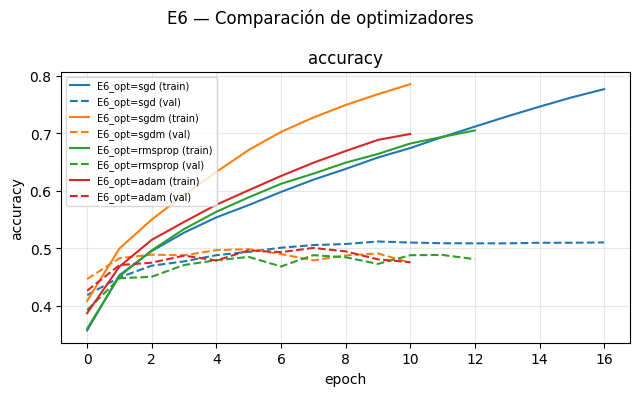

In [ ]:
experimento('E6_opt=sgd', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'sgd',
    'lr': 1e-2,
    'epochs': 40,
    'batch_size': 128
})

experimento('E6_opt=sgdm', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'sgdm',
    'lr': 1e-2,
    'epochs': 40,
    'batch_size': 128
})

experimento('E6_opt=rmsprop', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'rmsprop',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 128
})

reutilizar('E0_baseline', 'E6_opt=adam', {'optimizador': 'adam', 'lr': 1e-3})

display(tabla('E6', ['experimento', 'optimizador', 'lr', 'epocas', 'train_acc', 'val_acc', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E6')},
       'E6 — Comparación de optimizadores', claves=('accuracy',))

Las diferencias finales entre optimizadores fueron de $3.2$ puntos: SGD obtuvo $50.76\%$, SGD con momentum Nesterov $48.92\%$, RMSProp $47.94\%$ y Adam $47.52\%$. SGD con momentum fue el más rápido, con $50\%$ de val_accuracy en la epoch $5$ y $78\%$ de accuracy de entrenamiento en la epoch $11$, porque acumula la dirección del gradiente pasado. SGD simple fue más lento en entrenamiento, pero alcanzó $51\%$ de val_accuracy hacia la epoch $10$ y se mantuvo estable, obteniendo el mejor resultado del bloque.

SGD y SGD con momentum usaron $lr=0.01$, mientras que Adam y RMSProp usaron $lr=0.001$, por lo que este bloque no constituye un experimento perfectamente controlado, ya que sin tasa adaptativa, SGD avanzaría demasiado lento con $0.001$.

Pese a que SGD obtuvo el mejor resultado aislado, se mantiene Adam para el modelo final por tres razones: la comparación no es controlada (distinta tasa de aprendizaje); se realizó sin regularización, y la configuración final combina Adam con Batch Normalization, combinación ya validada en R2 ($55.66\%$); y reemplazar el optimizador exigiría reajustar la tasa de aprendizaje. Evaluar SGD dentro de la configuración regularizada queda como trabajo futuro.

# 6. Optimización y regularización
El diagnóstico del baseline mostró sobreajuste. Se aplican ahora las técnicas vistas en clases y se mide su impacto.

| Técnica | Qué hace | Por qué ayuda |
| --- | --- | --- |
| Dropout | Apaga al azar un $\%$ de neuronas en cada batch (solo en entrenamiento) | Fuerza representaciones redundantes; la red no puede depender de neuronas individuales |
| L2 / weight decay | Suma $\beta \cdot \sum \theta^2$ a la función de error | Penaliza pesos grandes $\Rightarrow$ funciones más suaves y menos sensibles al ruido |
| Batch Normalization | Normaliza las activaciones con media y varianza del mini-lote, con $\gamma$ y $\beta$ aprendibles | Estabiliza y acelera el entrenamiento; regulariza levemente |
| Early Stopping | Detiene el entrenamiento cuando `val_loss` deja de mejorar y restaura los mejores pesos | Corta en el punto de quiebre entre subajuste y sobreajuste |

## 6.1 Efecto del dropout

E7_dropout=0.0               | (reutilizado de E0_baseline) val_acc=0.4752
E7_dropout=0.2               | val_acc=0.5402 | brecha=+0.0717 | 33 epochs | 55.1s
E7_dropout=0.3               | val_acc=0.5380 | brecha=+0.0593 | 40 epochs | 69.2s
E7_dropout=0.5               | val_acc=0.4828 | brecha=-0.0177 | 40 epochs | 68.5s


,experimento,dropout,epocas,train_acc,val_acc,brecha,seg
20,E7_dropout=0.0,0.0,11,0.5148,0.4752,0.0396,19.6
21,E7_dropout=0.2,0.2,33,0.6119,0.5402,0.0717,55.1
22,E7_dropout=0.3,0.3,40,0.5973,0.5380,0.0593,69.2
23,E7_dropout=0.5,0.5,40,0.4651,0.4828,-0.0177,68.5


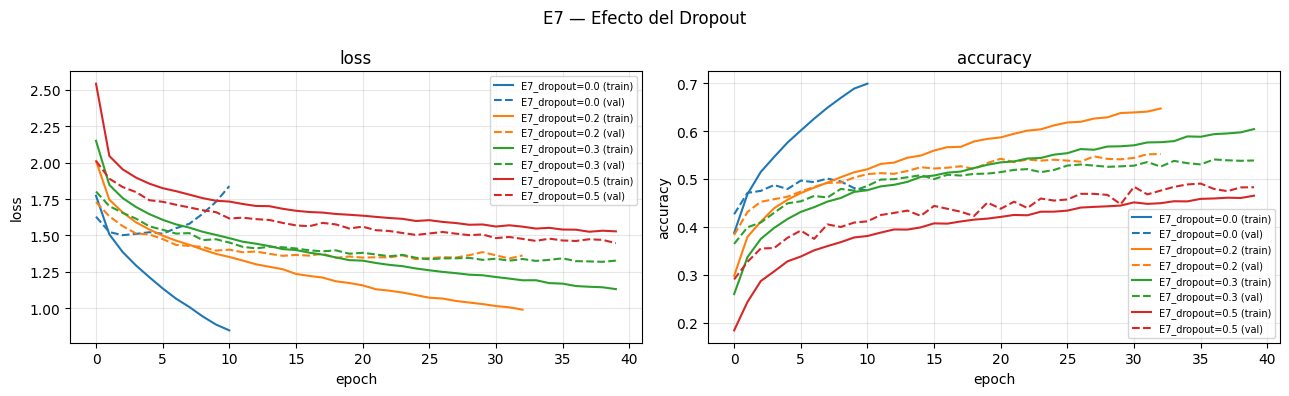

In [ ]:
reutilizar('E0_baseline', 'E7_dropout=0.0', {'dropout': 0.0})
for d in [0.2, 0.3, 0.5]:
    experimento(f'E7_dropout={d}', {
        'capas': (512, 256, 128),
        'activacion': 'relu',
        'optimizador': 'adam',
        'lr': 1e-3,
        'epochs': 40,
        'batch_size': 128,
        'dropout': d
    })

display(tabla('E7', ['experimento', 'dropout', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E7')},
       'E7 — Efecto del Dropout')

El dropout fue la técnica de mayor impacto de todo el trabajo. Con $0.2$, val_accuracy subió a $54.03\%$ (más de $6.5$ puntos sobre la baseline), y con $0.3$ a $53.80\%$ (más de $6.3$ puntos), siendo los mejores resultados de los bloques de hiperparámetros. Ambos modelos entrenaron muchas más epochs ($33$ a $40$, frente a $11$) porque, al apagar neuronas al azar, la red no puede memorizar el entrenamiento y val_loss sigue disminuyendo por más tiempo.

Con $0.5$, la regularización fue excesiva. El val_accuracy cayó a $48.28\ %$ y la brecha se volvió negativa ($1.8$ puntos menos), es decir, el modelo rindió peor en entrenamiento que en validación. Esto se debe a que la accuracy de entrenamiento se calcula con dropout activo (una red "debilitada"), mientras que la validación usa la red completa; con la mitad de las neuronas apagadas, el modelo entra en subajuste.

Se elige dropout = $0.3$: su diferencia con $0.2$ ($0.22$ puntos) no es significativa, presenta menor brecha ($5.9$ frente a $7.2$ puntos) y, a diferencia de $0.2$, alcanzó el límite de $40$ epochs sin converger, por lo que su potencial está subestimado.

## 6.2 Efecto de la regularización L2

E8_l2=0                      | (reutilizado de E0_baseline) val_acc=0.4752
E8_l2=1e-05                  | val_acc=0.4836 | brecha=+0.0597 | 12 epochs | 25.5s
E8_l2=0.0001                 | val_acc=0.4904 | brecha=+0.0482 | 12 epochs | 22.5s
E8_l2=0.001                  | val_acc=0.5040 | brecha=+0.0452 | 19 epochs | 35.4s


,experimento,l2,epocas,train_acc,val_acc,brecha,seg
24,E8_l2=0,0.0,11,0.5148,0.4752,0.0396,19.6
25,E8_l2=1e-05,1e-05,12,0.5433,0.4836,0.0597,25.5
26,E8_l2=0.0001,0.0001,12,0.5386,0.4904,0.0482,22.5
27,E8_l2=0.001,0.001,19,0.5492,0.5040,0.0452,35.4


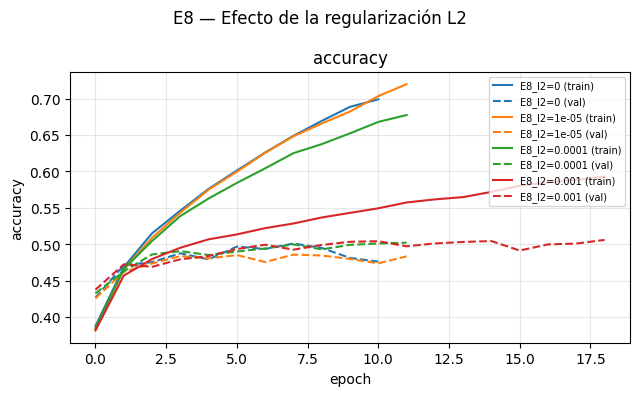

In [ ]:
reutilizar('E0_baseline', 'E8_l2=0', {'l2': 0.0})
for l2 in [1e-5, 1e-4, 1e-3]:
    experimento(f'E8_l2={l2:g}', {
        'capas': (512, 256, 128),
        'activacion': 'relu',
        'optimizador': 'adam',
        'lr': 1e-3,
        'epochs': 40,
        'batch_size': 128,
        'l2': l2
    })

display(tabla('E8', ['experimento', 'l2', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']))
curvas({k: v for k, v in historiales.items() if k.startswith('E8')},
       'E8 — Efecto de la regularización L2', claves=('accuracy',))

La regularización L2 tuvo un efecto moderado y, en el rango probado, creciente con $\beta = 10^{-3}$ obtuvo $48.36\%$ ($0.8$ puntos más), $10^{4}$ obtuvo $49.04\%$ ($1.5$ puntos más) y $10^{-3}$ obtuvo $50.40\%$ ($2.9$ puntos más), necesitando $19$ epochs. El beneficio máximo es menos de la mitad del obtenido con dropout.

Las brechas de los modelos con L2 ($4.5$ a $6.0$ puntos) son mayores que la del baseline ($4.0$), pero no porque sobreajusten más: al detenerse más tarde, se miden en una epoch en que el entrenamiento ya avanzó más. Aunque el mejor valor aislado fue $10^{-3}$, en la configuración final se usa $10^{-4}$: al combinarse con dropout y Batch Normalization, la regularización total aumenta, y un $β$ alto podría sobre-regularizar el modelo. R2 confirma que la combinación funciona. Determinar el $β$ óptimo en combinación queda como trabajo futuro.


## 6.3 Comparación integral - Con y sin optimización
Evidencia central del trabajo: tres modelos idénticos salvo por la regularización aplicada.

R0_sin_regularizacion        | (reutilizado de E0_baseline) val_acc=0.4752
R1_dropout                   | (reutilizado de E7_dropout=0.3) val_acc=0.5380
R2_dropout+L2+BN             | val_acc=0.5566 | brecha=+0.0137 | 28 epochs | 55.4s


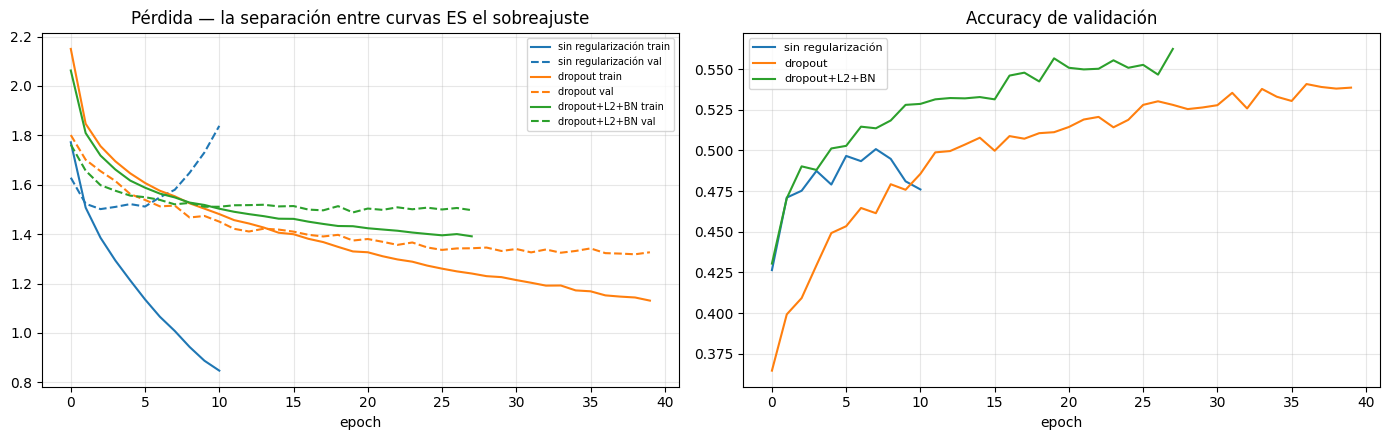

,experimento,dropout,l2,batchnorm,epocas,train_acc,val_acc,brecha
28,R0_sin_regularizacion,0.0,0.0,False,11,0.5148,0.4752,0.0396
29,R1_dropout,0.3,0.0,False,40,0.5973,0.5380,0.0593
30,R2_dropout+L2+BN,0.3,0.0001,True,28,0.5703,0.5566,0.0137


In [ ]:
reutilizar('E0_baseline', 'R0_sin_regularizacion', {'dropout': 0.0, 'l2': 0.0, 'batchnorm': False})
reutilizar('E7_dropout=0.3', 'R1_dropout', {'dropout': 0.3, 'l2': 0.0, 'batchnorm': False})
experimento('R2_dropout+L2+BN', {
    'capas': (512, 256, 128),
    'activacion': 'relu',
    'optimizador': 'adam',
    'lr': 1e-3,
    'epochs': 40,
    'batch_size': 128,
    'dropout': 0.3,
    'l2': 1e-4,
    'batchnorm': True
})

h_sin, h_do, h_full = (historiales['R0_sin_regularizacion'],
                       historiales['R1_dropout'], historiales['R2_dropout+L2+BN'])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.5))
for nom, h in [('sin regularización', h_sin), ('dropout', h_do), ('dropout+L2+BN', h_full)]:
    p = a1.plot(h.history['loss'], label=f'{nom} train')
    a1.plot(h.history['val_loss'], '--', color=p[0].get_color(), label=f'{nom} val')
    a2.plot(h.history['val_accuracy'], label=nom)
a1.set_title('Pérdida — la separación entre curvas ES el sobreajuste')
a1.set_xlabel('epoch'); a1.legend(fontsize=7); a1.grid(alpha=.3)
a2.set_title('Accuracy de validación'); a2.set_xlabel('epoch')
a2.legend(fontsize=8); a2.grid(alpha=.3)
plt.tight_layout(); plt.show()

display(tabla('R', ['experimento', 'dropout', 'l2', 'batchnorm',
                    'epocas', 'train_acc', 'val_acc', 'brecha']))

La comparación muestra con claridad el efecto de la regularización. Sin regularización, la val_loss alcanza su mínimo en la epoch $3$ y luego aumenta de $1.50$ a $1.83$, mientras la pérdida de entrenamiento desciende hasta $0.85$: las curvas se separan desde muy temprano. Con dropout, las curvas de entrenamiento y validación se mantienen juntas, la val_loss desciende de forma sostenida hasta $1.32$ y la val_accuracy sube a $53.80\%$ ($6.3$ puntos más), aunque sin terminar de converger en $40$ epochs.

La combinación de dropout, L2 y Batch Normalization obtuvo la mejor val_accuracy de todos los experimentos ($55.66\%$, con $8.1$ puntos más sobre el baseline), con una brecha de solo $1.4$ puntos y una convergencia mucho más rápida: alcanzó $53\%$ en la epoch $11$, cuando el modelo solo con dropout necesitó cerca de $26$ epochs. Esto se atribuye a Batch Normalization, que normaliza las activaciones de cada capa y mantiene el gradiente en un rango estable.

En el modelo con dropout, la pérdida de entrenamiento se mantiene por encima de la de validación durante las primeras $15$ epochs. No es un error: el dropout solo actúa durante el entrenamiento y la penalización L2 se suma a la pérdida de entrenamiento pero no a la de validación. En síntesis, la regularización mejoró la accuracy entre $6.3$ y $8.1$ puntos y estabilizó el entrenamiento.


# 7. Modelo final y evaluación
## 7.1 Selección de la configuración
| Hiperparámetro | Valor elegido | Evidencia | Razón |
|---|---|---|---|
| Tasa de aprendizaje | $0.001$ | E1 | $0.01$ diverge; $0.0001$ da $+2.2$ pts pero con brecha de $12.3$; Batch Normalization tolera $0.001$ |
| Batch size |128 | E2 | Diferencias < $1.8$ pts; $32$ triplica el tiempo y $512$ tiene la mayor brecha ($10.7$ pts) |
| Arquitectura | $512-256-128$ | E3 | Diferencias $≤ 1.6 pts$; equilibrio entre capacidad y costo |
| Activación | ReLu | E4 | Diferencias $≤ 0.34$ pts con ELU y sigmoide; coherente con He; escala en profundidad |
| Pérdida | Entropía cruzada | E5 | La ventaja del MSE es un artefacto del early stopping |
| Optimizador | Adam | E6 | SGD dio $+3.2$ pts en una comparación no controlada; Adam + BN validado en R2 |
| Dropout | 0.3 | E7 | $+6.3$ pts; diferencia con $0.2$ no significativa y menor brecha |
| L2 | $10⁻⁴$ | E8 | Valor intermedio para no sobre-regularizar en combinación |
| Batch Normalization | Sí | R2 | Mejor val_accuracy ($55.66\%$) y convergencia $2.5$ veces más rápida |
| epochs máximas | $80$, paciencia $10$ | E7 | Dropout $0.3$ alcanzó el límite de 40 sin converger |

Combinar los mejores valores de cada experimento por separado no garantiza el mejor modelo combinado, porque los hiperparámetros interactúan: por ejemplo, Batch Normalization permite usar una tasa de aprendizaje mayor, y la regularización total depende de la combinación de dropout y L2.

FINAL                        | val_acc=0.5474 | brecha=+0.0125 | 28 epochs | 54.2s


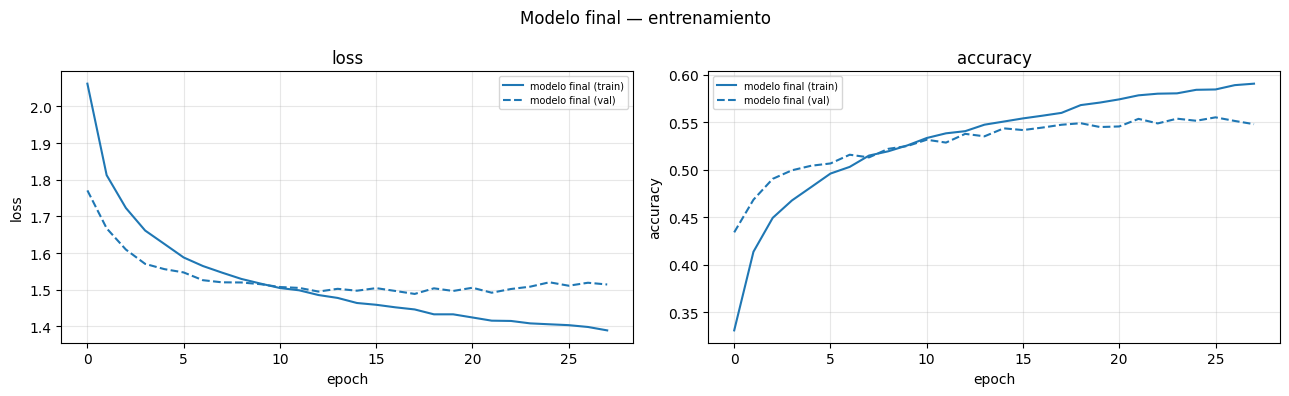

In [ ]:
CONFIG_FINAL = dict(capas=(512, 256, 128), activacion='relu',
                    dropout=0.3, l2=1e-4, batchnorm=True,
                    optimizador='adam', lr=1e-3,
                    epochs=80, batch_size=128, paciencia=10)

modelo_final, h_final = experimento('FINAL', CONFIG_FINAL)
curvas({'modelo final': h_final}, 'Modelo final — entrenamiento')

## 7.2 Evaluación sobre el conjunto de prueba
Este es el único momento en que se utiliza el conjunto de prueba. Todas las decisiones anteriores se tomaron observando exclusivamente el conjunto de validación.

### Cómo se calcula cada métrica
Para una clase $c$, con $\text{TP}$ = verdaderos positivos, $\text{FP}$ = falsos positivos y $\text{FN}$ = falsos negativos:

```
Accuracy  = aciertos totales / total de ejemplos

Precision = TP / (TP + FP)    "de todo lo que predije como gato, ¿qué fracción era gato?"

Recall    = TP / (TP + FN)    "de todos los gatos que existían, ¿cuántos encontré?"

F1        = 2 · Precision · Recall / (Precision + Recall)    media armónica de ambas
```

- macro: promedia las $10$ clases con el mismo peso.
- weighted: pondera por el número de ejemplos de cada clase.

In [ ]:
y_prob = modelo_final.predict(X_test, verbose=0)   # (10000, 10) probabilidades softmax
y_pred = np.argmax(y_prob, axis=1)                 # decisión discreta

resumen = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision (macro)', 'Recall (macro)',
                'F1-score (macro)', 'F1-score (weighted)'],
    'Valor':   [accuracy_score(y_test, y_pred),
                precision_score(y_test, y_pred, average='macro'),
                recall_score(y_test, y_pred, average='macro'),
                f1_score(y_test, y_pred, average='macro'),
                f1_score(y_test, y_pred, average='weighted')]})
resumen['Valor'] = resumen['Valor'].round(4)
display(resumen)

print(classification_report(y_test, y_pred, target_names=CLASES, digits=3))

,Métrica,Valor
0,Accuracy,0.5499
1,Precision (macro),0.5533
2,Recall (macro),0.5499
3,F1-score (macro),0.5471
4,F1-score (weighted),0.5471


              precision    recall  f1-score   support

    airplane      0.601     0.635     0.618      1000
  automobile      0.664     0.631     0.647      1000
        bird      0.534     0.334     0.411      1000
         cat      0.357     0.397     0.376      1000
        deer      0.473     0.507     0.489      1000
         dog      0.464     0.398     0.429      1000
        frog      0.518     0.719     0.602      1000
       horse      0.625     0.619     0.622      1000
        ship      0.700     0.654     0.676      1000
       truck      0.597     0.605     0.601      1000

    accuracy                          0.550     10000
   macro avg      0.553     0.550     0.547     10000
weighted avg      0.553     0.550     0.547     10000



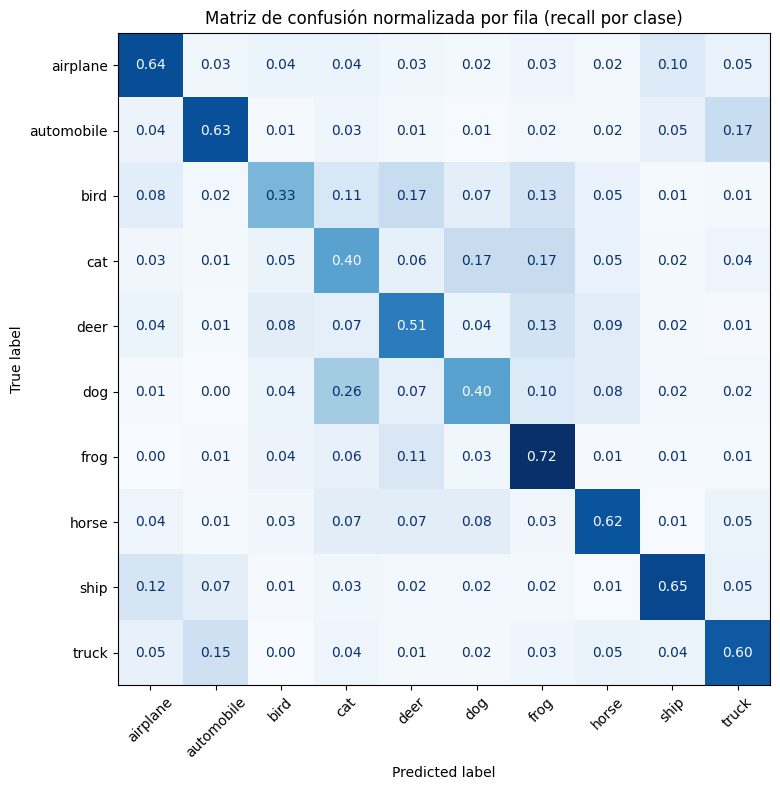

Clases más difíciles: [('cat', np.float64(0.376)), ('bird', np.float64(0.411)), ('dog', np.float64(0.429))]
Clases más fáciles  : [('ship', np.float64(0.676)), ('automobile', np.float64(0.647)), ('horse', np.float64(0.622))]

Confusiones más frecuentes (real -> predicho):
  dog        -> cat       : 25.8% de los dog
  cat        -> dog       : 17.5% de los cat
  cat        -> frog      : 17.4% de los cat
  bird       -> deer      : 17.2% de los bird
  automobile -> truck     : 17.0% de los automobile


In [ ]:
cm = confusion_matrix(y_test, y_pred, normalize='true')
fig, ax = plt.subplots(figsize=(9, 8))
ConfusionMatrixDisplay(cm, display_labels=CLASES).plot(
    ax=ax, xticks_rotation=45, cmap='Blues', values_format='.2f', colorbar=False)
plt.title('Matriz de confusión normalizada por fila (recall por clase)')
plt.tight_layout(); plt.show()

# Ranking de clases por F1 y pares más confundidos
f1_clases = f1_score(y_test, y_pred, average=None)
orden = np.argsort(f1_clases)
print("Clases más difíciles:", [(CLASES[i], round(f1_clases[i], 3)) for i in orden[:3]])
print("Clases más fáciles  :", [(CLASES[i], round(f1_clases[i], 3)) for i in orden[-3:][::-1]])

cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
pares = np.dstack(np.unravel_index(np.argsort(cm_off.ravel())[::-1], cm_off.shape))[0][:5]
print("\nConfusiones más frecuentes (real -> predicho):")
for r, p in pares:
    print(f"  {CLASES[r]:10s} -> {CLASES[p]:10s}: {cm_off[r, p]:.1%} de los {CLASES[r]}")

## 7.3 Interpretación de las métricas
El modelo final obtuvo sobre el conjunto de prueba una accuracy de $54.99\%$, precision macro de $0.553$, recall macro de $0.550$ y F1 macro de $0.547$. Los promedios macro y weighted son idénticos porque el conjunto de prueba está balanceado (1 000 imágenes por clase). La accuracy en prueba ($54.99\%$) es prácticamente igual a la de validación ($54.74\%$), lo que indica que el conjunto de validación fue un estimador confiable y que no hubo fuga de información.

Las clases con peor desempeño son cat (F1 = $0.376$), bird ($0.411$) y dog ($0.429$); las mejores son ship ($0.676$), automobile ($0.647$) y horse ($0.622$). La confusión más frecuente es mutua entre perros y gatos: el $25.8\%$ de los perros se clasifica como gato y el $17.5\%$ de los gatos como perro. Le siguen gato → rana ($17.4\%$), ave → ciervo ($17.2\%$) y automóvil → camión ($17.0\%$).

La clase frog funciona como sumidero de animales: recibe el $17\%$ de los gatos, el $13\%$ de las aves, el $13\%$ de los ciervos y el $10\%$ de los perros. Por eso tiene el recall más alto del modelo ($0.719$) pero una precision de solo $0.518$. Estos pares no comparten forma sino tonos verdes y cafés de vegetación y pelaje, igual que ave–ciervo, o el cielo y el mar en avión → barco ($10\%$) y barco → avión ($12\%$). El modelo se apoya principalmente en el color y la textura global, que es lo único que un MLP puede capturar tras el aplanado, y no en la forma del objeto.

Como ejemplo del cálculo: de los $1 000$ gatos reales el modelo detectó $397$ (recall = $0.397$), pero predijo "cat" para unas $1 112$ imágenes, de las cuales solo esas $397$ eran gatos (precision = $0.357$). Así, F1 = $2 × 0.357 × 0.397 / (0.357 + 0.397$) ≈ $0.376$.

## 7.4 Inspección cualitativa de predicciones

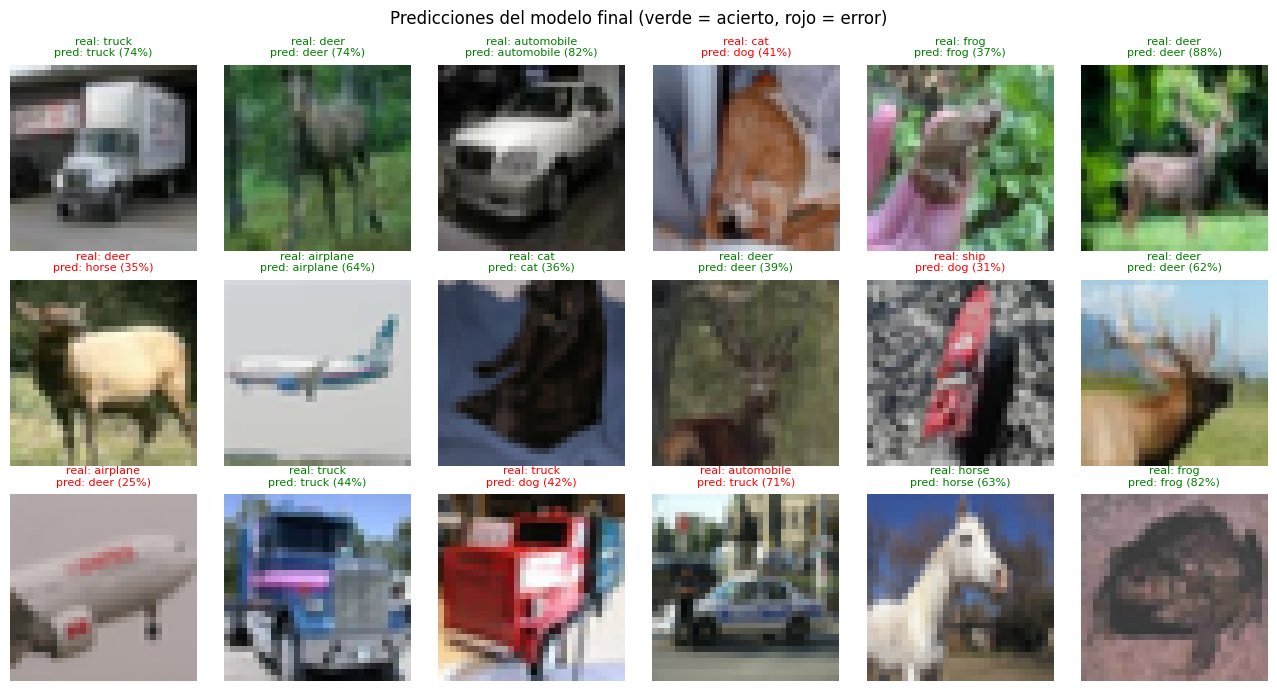

In [ ]:
fig, axs = plt.subplots(3, 6, figsize=(13, 7))
for ax in axs.ravel():
    k = np.random.randint(len(X_test))
    img = np.clip(X_test[k] * sigma + mu, 0, 255).astype('uint8')   # deshacemos la estandarización
    ax.imshow(a_imagen(img)); ax.axis('off')
    ok = (y_pred[k] == y_test[k])
    ax.set_title(f"real: {CLASES[y_test[k]]}\npred: {CLASES[y_pred[k]]} ({y_prob[k].max():.0%})",
                 fontsize=8, color='green' if ok else 'red')
plt.suptitle('Predicciones del modelo final (verde = acierto, rojo = error)')
plt.tight_layout(); plt.show()

En la muestra de 18 imágenes, el modelo acertó $12$ ($67\%$), una proporción coherente con su accuracy global. La mayoría de los errores corresponde a clases visualmente similares: gato → perro, ciervo → caballo (cuadrúpedos de tonos café) y automóvil → camión. El error de menor confianza ($25\%$) es un avión clasificado como ciervo: se trata de un dirigible sobre un fondo claro uniforme, sin las alas que lo distinguirían. Otros dos errores son menos razonables (barco → perro y camión → perro), pero ambos corresponden a encuadres muy cerrados de objetos rojos sobre fondos con textura, poco representativos de su clase.

El modelo muestra una calibración razonable: sus aciertos tienen una confianza promedio de $62\%$ y sus errores de $41\%$, con cinco de seis errores por debajo de $45\%$. Cuando se equivoca, generalmente "duda". La excepción es automóvil → camión con $71\%$, una confusión entre clases genuinamente cercanas. También destaca la clase cat: el único gato acertado tiene solo $36\%$ de confianza, y el otro fue clasificado como perro, coherente con que cat es la clase con peor F1.

# 8. Análisis comparativo global

,experimento,epocas,train_acc,val_acc,brecha,seg
0,R2_dropout+L2+BN,28,0.5703,0.5566,0.0137,55.4
1,FINAL,28,0.5599,0.5474,0.0125,54.2
2,E7_dropout=0.2,33,0.6119,0.5402,0.0717,55.1
3,E7_dropout=0.3,40,0.5973,0.5380,0.0593,69.2
4,E6_opt=sgd,17,0.6381,0.5076,0.1305,28.2
5,E8_l2=0.001,19,0.5492,0.5040,0.0452,35.4
6,E1_lr=0.0001,13,0.6210,0.4976,0.1234,23.4
7,E5_loss=mse,15,0.5939,0.4952,0.0987,25.5
8,E2_batch=512,13,0.6002,0.4930,0.1072,15.7
9,E3_capas=4x1024,12,0.5403,0.4912,0.0491,24.0


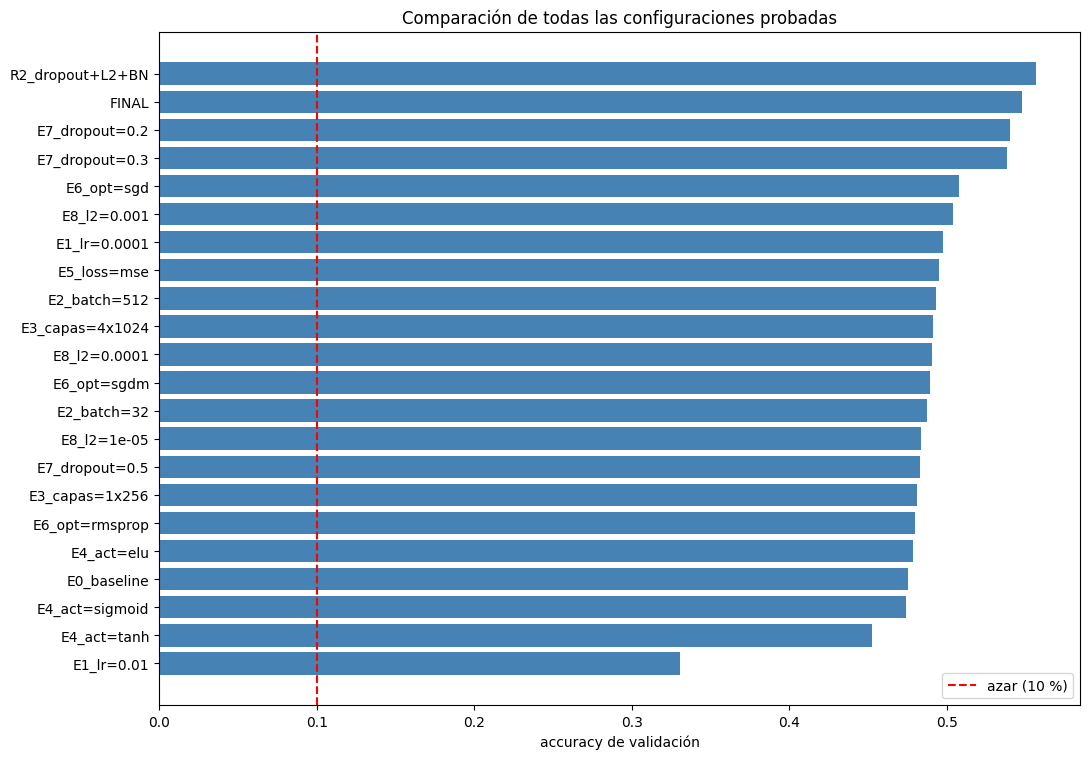

In [ ]:
resumen_global = (pd.DataFrame(resultados)
                  .drop_duplicates(subset=['val_acc', 'train_acc', 'epocas'])  # sin repetir reutilizados
                  [['experimento', 'epocas', 'train_acc', 'val_acc', 'brecha', 'seg']]
                  .sort_values('val_acc', ascending=False)
                  .reset_index(drop=True))
display(resumen_global)

plt.figure(figsize=(11, max(4, 0.35*len(resumen_global))))
plt.barh(resumen_global['experimento'], resumen_global['val_acc'], color='steelblue')
plt.axvline(0.10, color='red', ls='--', label='azar (10 %)')
plt.xlabel('accuracy de validación'); plt.gca().invert_yaxis()
plt.title('Comparación de todas las configuraciones probadas')
plt.legend(); plt.tight_layout(); plt.show()

## 8.1 Análisis de hallazgos y experimentos

Para identificar los hiperparámetros más influyentes se calculó, dentro de cada bloque, la diferencia entre la mejor y la peor `val_accuracy`:

| Bloque | Rango de `val_accuracy` | Variación |
| --- | --- | --- |
| E1 Tasa de aprendizaje | $33.06\%$ - $49.76\%$ | $16.70$ pts |
| E7 Dropout | $47.52\%$ - $54.02\%$ | $6.50$ pts |
| E6 Optimizador | $47.52\%$ - $50.76\%$ | $3.24$ pts |
| E8 L2 | $47.52\%$ - $50.40\%$ | $2.88$ pts |
| E4 Activación | $45.22\%$ - $47.86\%$ | $2.64$ pts |
| E5 Pérdida | $47.52\%$ - $49.52\%$ | $2.00$ pts |
| E2 Batch size | $47.52\%$ - $49.30\%$ | $1.78$ pts |
| E3 Arquitectura | $47.52\%$ - $49.12\%$ | $1.60$ pts |

| Hallazgo | Evidencia | Explicación técnica |
| --- | --- | --- |
| La tasa de aprendizaje es el hiperparámetro más determinante | E1: $33.06\ \%$ con `lr=0.01` (diverge) vs $49.76\ \%$ con `0.0001` | Un paso excesivo aleja al optimizador del mínimo en lugar de asentarlo en él |
| El dropout es la técnica de regularización más efectiva | E7: $6.50$ pts más con `0.2` y $6.28$ con `0.3` | Fuerza representaciones redundantes e impide la memorización |
| Más capacidad no mejora la generalización | E3: duplicar parámetros (de $1.74$ a $3.84$ millones) aporta $1.60$ pts | El límite es la representación aplanada, no el número de neuronas |
| Batch Normalization acelera la convergencia | R2 llega a $\approx 53\ \%$ en $11$ epochs vs $\approx 26$ con solo dropout | Normaliza las activaciones y estabiliza el gradiente |
| El criterio de early stopping sesga las comparaciones | E5: MSE ($49.52\ \%$) "supera" a la entropía cruzada ($47.52\ \%$) solo por entrenar más epochs ($15$ vs $11$) | La `val_loss` de la entropía cruzada sube temprano por sobreconfianza |
| La misma configuración varía cerca de $1$ punto entre ejecuciones | R2 ($55.66\ \%$) vs FINAL ($54.74\ \%$), con igual configuración y semilla | No determinismo de las operaciones en GPU |

La mejor val_accuracy la obtuvo R2 ($55.66\%$), no el modelo final ($54.74\%$), pese a que su configuración es idéntica salvo por la paciencia del early stopping ($8$ vs $10$) y el máximo de epochs ($40$ vs $80$). Ese resultado es revelador: la paciencia solo actúa después de la mejor epoch, por lo que, con la misma semilla, ambos entrenamientos debieron ser idénticos durante las primeras 28 epochs. No lo fueron: R2 encontró su mejor epoch en la 20 y el modelo final en la 18. Esto evidencia el no determinismo de las operaciones en GPU, que con la misma configuración y semilla produjo una diferencia de 0.9 puntos. Se mantiene el modelo final evaluado, ya que su diferencia con R2 está dentro de ese margen de ruido.

Se reconocen dos limitaciones metodológicas. Primero, la propia comparación entre R2 y el modelo final muestra que la misma configuración puede variar cerca de $1$ punto entre ejecuciones, por lo que diferencias menores a $1.5$ puntos no son concluyentes. Segundo, el early stopping basado en `val_loss` favorece a las configuraciones que aprenden más lento, porque les permite entrenar más epochs antes de detenerse. Como mejora, se propone monitorear `val_accuracy` y repetir cada experimento con varias semillas.

# 9. Conclusiones

## 9.1 Resultados obtenidos
El modelo final alcanzó un $54.99\%$ de accuracy y $0.547$ de F1-score macro sobre el conjunto de prueba, lo que representa un rendimiento más de $5$ veces superior al azar ($10\%$) y se sitúa en el extremo superior del rango esperado ($45–55\%$) para una arquitectura MLP sobre CIFAR-10.

## 9.2 Hiperparámetros más influyentes
Los hiperparámetros de mayor impacto fueron la tasa de aprendizaje ($16.7$ pts, con divergencia en lr = $0.01$) y el dropout ($$ pts). La activación tuvo menos impacto del esperado ($2.6$ pts): la sigmoide ralentizó el aprendizaje, pero con 3 capas no degradó el resultado final.

## 9.3 Impacto de la regularización
La regularización fue clave para mitigar el sobreajuste. Al combinar Dropout ($0.3$), L2 ($10^{-4}$) y Batch Normalization, la brecha de generalización se redujo drásticamente a solo +$0.0125$, frente a $22$ puntos al final del entrenamiento del baseline, con lo que se logró un entrenamiento sumamente robusto y consistente.

## 9.4 Limitaciones del modelo
El aplanado de la imagen a un vector de $3\ 072$ componentes destruye por completo la estructura espacial bidimensional. Por esta razón, el modelo se apoya principalmente en la información de color global (por ejemplo, el fondo azul en la clase `ship`) y comete errores lógicos al clasificar formas complejas, lo que se traduce en la confusión sistemática de gatos con perros.

## 9.5 Mejoras propuestas
* Redes Convolucionales (CNN): Implementar capas convolucionales para preservar la coherencia espacial y obtener invariabilidad ante traslaciones.
* Aumento de Datos (Data Augmentation): Utilizar rotaciones leves y volteos horizontales para dotar de mayor variabilidad al entrenamiento.
* Búsqueda de hiperparámetros avanzada: Emplear Grid Search o Random Search para optimizar de manera automatizada el espacio de búsqueda.